In [1]:
from typing import Callable, List, Optional, Tuple, Union
from joblib import Parallel, delayed
from functools import partial

import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.optimize import OptimizeResult, minimize
import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

import re
from tqdm.notebook import tqdm
## 用于监控
import contextlib
from joblib.parallel import BatchCompletionCallBack

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    old_batch_callback = BatchCompletionCallBack.__call__

    def new_batch_callback(self, *args, **kwargs):
        tqdm_object.update(n=self.batch_size)
        return old_batch_callback(self, *args, **kwargs)

    BatchCompletionCallBack.__call__ = new_batch_callback
    try:
        yield tqdm_object
    finally:
        BatchCompletionCallBack.__call__ = old_batch_callback
        tqdm_object.close()

In [2]:
def arrowed_spines(ax, columns, background="white"):
    """
    画左下角箭头的函数，引自dynamo
    """
    if type(columns) == str:
        columns = [columns.upper() + " 1", columns.upper() + " 2"]
    import matplotlib.pyplot as plt

    fig = plt.gcf()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    despline_all(ax)

    # removing the axis ticks
    deaxis_all(ax)

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length (x-axis)
    hw = 1.0 / 20.0 * (ymax - ymin)
    hl = 1.0 / 20.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.2  # arrow overhang

    # compute matching arrowhead length and width (y-axis)
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    fc, ec = ("w", "w") if background in ["black", "#ffffff"] else ("k", "k")
    ax.arrow(
        xmin,
        ymin,
        hl * 5 / 2,
        0,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=hw / 2,
        head_length=hl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )
    ax.arrow(
        xmin,
        ymin,
        0,
        hw * 5 / 2,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=yhw / 2,
        head_length=yhl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )

    ax.text(
        xmin + hl * 2.5 / 2,
        ymin - 1.5 * hw / 2,
        columns[0],
        ha="center",
        va="center",
        rotation=0,
        # size=hl * 5 / (2 * len(str(columns[0]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )
    ax.text(
        xmin - 1.5 * yhw / 2,
        ymin + hw * 2.5 / 2,
        columns[1],
        ha="center",
        va="center",
        rotation=90,
        # size=hw * 5 / (2 * len(str(columns[1]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )

    return ax

def despline_all(ax=None, sides=None):
    # removing the default axis on all sides:
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    if sides is None:
        sides = ["bottom", "right", "top", "left"]
    for side in sides:
        ax.spines[side].set_visible(False)


def deaxis_all(ax=None):
    # removing the axis ticks
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [3]:
## 读取相位点
basin_point = loadmat('basin_point.mat')['basinpoint']
basin_point.shape

(3, 20)

In [4]:
## 计算作用量的函数
def action(path: np.ndarray, vf_func: Callable[[np.ndarray], np.ndarray], D: float = 1, dt: float = 1) -> float:
    """The action function calculates the action (or functional) of a path in space, given a velocity field function
    and diffusion coefficient.

    The path is represented as an array of points in space, and the velocity field is given by vf_func. The function
    first calculates the centers of the segments between each point in the path, and then calculates the velocity at
    each of these centers by taking the average of the velocities at the two neighboring points. The difference
    between the actual velocity and the velocity field at each center is then calculated and flattened into a
    one-dimensional array. The action is then calculated by taking the dot product of this array with itself,
    multiplying by a factor of 0.5*dt/D, where dt is the time step used to define the path, and D is the diffusion
    coefficient.

    Args:
        path: An array of shape (N, d) containing the coordinates of a path with N points in d dimensions.
        vf_func: A callable that takes an array of shape (d,) as input and returns a vector field at that point.
        D: A scalar representing the diffusion coefficient.
        dt: A scalar representing the time step size.

    Returns:
        A scalar representing the action along the path.
    """
    x = (path[:-1] + path[1:]) * 0.5
    v = np.diff(path, axis=0) / dt

    s = (v - vf_func(x)).flatten()
    s = 0.5 * s.dot(s) * dt / D

    return s


def action_aux(
    path_flatten: np.ndarray,
    vf_func: Callable,
    dim: int,
    start: Optional[np.ndarray] = None,
    end: Optional[np.ndarray] = None,
    **kwargs,
) -> float:
    """Auxiliary function for computing the action of a path.

    Args:
        path_flatten: A 1D array representing the flattened path.
        vf_func: A function that computes the velocity field vf(x) for a given position x.
        dim: The dimension of the path.
        start: The starting point of the path.
        end: The end point of the path.
        **kwargs: Additional keyword arguments to pass to the action function.

    Returns:
        The action of the path.
    """
    path = reshape_path(path_flatten, dim, start=start, end=end)
    return action(path, vf_func, **kwargs)


def action_grad(path: np.ndarray, vf_func: Callable, jac_func: Callable, D: float = 1.0, dt: float = 1.0) -> np.ndarray:
    """Computes the gradient of the action functional with respect to the path.

    Args:
        path: A 2D array of shape (n+1,d) representing the path, where n is the number of time steps and d is the
            dimension of the path.
        vf_func: A function that computes the velocity field vf(x) for a given position x.
        jac_func: A function that computes the Jacobian matrix of the velocity field at a given position.
        D: The diffusion constant (default is 1).
        dt: The time step (default is 1).

    Returns:
        The gradient of the action functional with respect to the path, as a 2D array of shape (n,d).
    """
    x = (path[:-1] + path[1:]) * 0.5
    v = np.diff(path, axis=0) / dt

    dv = v - vf_func(x)
    J = jac_func(x)
    z = np.zeros(dv.shape)
    for s in range(dv.shape[0]):
        z[s] = dv[s] @ J[:, :, s]
    grad = (dv[:-1] - dv[1:]) / D - dt / (2 * D) * (z[:-1] + z[1:])
    return grad


def action_grad_aux(
    path_flatten: np.ndarray,
    vf_func: Callable,
    jac_func: Callable,
    dim: int,
    start: Optional[np.ndarray] = None,
    end: Optional[np.ndarray] = None,
    **kwargs,
) -> np.ndarray:
    """Auxiliary function for computing the gradient of the action functional with respect to the path.

    Args:
        path_flatten: A 1D array representing the flattened path.
        vf_func: A function that computes the velocity field vf(x) for a given position x.
        jac_func: A function that computes the Jacobian matrix of the velocity field at a given position.
        dim: The dimension of the path.
        start: The starting point of the path.
        end: The end point of the path.
        **kwargs: Additional keyword arguments to pass to the action_grad function.

    Returns:
        The gradient of the action functional with respect to the path.
    """
    path = reshape_path(path_flatten, dim, start=start, end=end)
    return action_grad(path, vf_func, jac_func, **kwargs).flatten()


def reshape_path(
    path_flatten: np.ndarray,
    dim: int,
    start: Optional[np.ndarray] = None,
    end: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Reshapes a flattened path into a 2D array.

    Args:
        path_flatten: A 1D array representing the flattened path.
        dim: The dimension of the path.
        start: The starting point of the path.
        end: The end point of the path.

    Returns:
        A 2D array representing the path.
    """
    path = path_flatten.reshape(int(len(path_flatten) / dim), dim)
    if start is not None:
        path = np.vstack((start, path))
    if end is not None:
        path = np.vstack((path, end))
    return path

In [5]:
## 量化LAP
def lap_T(
    path_0: List[np.ndarray],
    T: float,
    vf_func: Callable[[np.ndarray], np.ndarray],
    jac_func: Callable[[np.ndarray], np.ndarray],
    D: float = 1,
) -> Tuple[np.ndarray, float, float]:
    """
    Compute a time-optimal path between two points with a given velocity field.

    Args:
        path_0: An array of points representing the initial path, where each point is a list of floats.
        T: A float representing the maximum time to reach the end of the path.
        vf_func: A function that takes a point and returns a velocity vector as an array.
        jac_func: A function that takes a point and returns the Jacobian matrix of the velocity field
            at that point as an array.
        D: A float representing the cost per unit of time.

    Returns:
        A tuple containing the following elements:
        - path_sol: An array of points representing the optimized path.
        - dt_sol: A float representing the time step used to compute the optimized path.
        - action_opt: A float representing the minimum action (cost) of the optimized path.
    """
    n = len(path_0)
    dt = T / (n - 1)
    dim = len(path_0[0])

    def fun(x):
        return action_aux(x, vf_func, dim, start=path_0[0], end=path_0[-1], D=D, dt=dt)

    def jac(x):
        return action_grad_aux(x, vf_func, jac_func, dim, start=path_0[0], end=path_0[-1], D=D, dt=dt)

    sol_dict = minimize(fun, path_0[1:-1].flatten(), jac=jac)
    path_sol = reshape_path(sol_dict["x"], dim, start=path_0[0], end=path_0[-1])

    # further optimization by varying dt
    t_dict = minimize(lambda t: action(path_sol, vf_func, D=D, dt=t), dt, bounds=[(1e-8, None)])
    action_opt = t_dict["fun"]
    dt_sol = t_dict["x"][0]

    return path_sol, dt_sol, action_opt


def least_action_path(
    start: np.ndarray,
    end: np.ndarray,
    vf_func: Callable[[np.ndarray], np.ndarray],
    jac_func: Callable[[np.ndarray], np.ndarray],
    n_points: int = 20,
    init_path: Optional[np.ndarray] = None,
    D: float = 1,
    dt_0: float = 1,
    EM_steps: int = 2,
) -> Tuple[np.ndarray, float, float]:
    """
    Computes the least action path between two points in a given vector field.

    Args:
        start: The starting point of the path.
        end: The end point of the path.
        vf_func: A function that computes the vector field at a given point.
        jac_func: A function that computes the Jacobian of the vector field at a given point.
        n_points: The number of points to use in the initial path.
        init_path: An optional initial path to use instead of the default linear path.
        D: The diffusion coefficient.
        dt_0: The initial time step to use.
        EM_steps: The number of expectation-maximization steps to use in the Laplace method.

    Returns:
        A tuple containing the least action path, the optimal time step, and the minimum action value.
    """
    if init_path is None:
        path = (
            np.tile(start, (n_points + 1, 1))
            + (np.linspace(0, 1, n_points + 1, endpoint=True) * np.tile(end - start, (n_points + 1, 1)).T).T
        )
    else:
        path = np.array(init_path, copy=True)

    # initial dt estimation:
    t_dict = minimize(lambda t: action(path, vf_func, D=D, dt=t), dt_0, bounds=[(1e-8, None)])
    dt = t_dict["x"][0]

    while EM_steps > 0:
        EM_steps -= 1
        path, dt, action_opt = lap_T(path, dt * n_points, vf_func, jac_func, D=D)

    return path, dt, action_opt

In [6]:
## 神经网络框架
class Encoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 128,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_int, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2_mean = nn.Linear(n_hidden, n_latent)
        self.fc2_logvar = nn.Linear(n_hidden, n_latent)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

class Decoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 20,
        n_hidden: int = 128,
        batch_norm: bool = False,
    ):
        super().__init__()
        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_latent, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        # self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2 = nn.Linear(n_hidden, n_int)

    def forward(self, z: torch.Tensor):
        z = self.fc1(z)
        recon_x = self.fc2(z)
        return recon_x

class LatentODE(nn.Module):
    def __init__(
        self,
        n_latent: int = 20,
        n_hidden: int = 32,
    ):
        super(LatentODE, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=n_latent, out_features=n_hidden, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_hidden, bias=True),
            nn.BatchNorm1d(n_hidden),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_latent, bias=True)
            )

    def forward(self, t, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
        return output

In [7]:
## 加载训练好的模型
encoder = Encoder(n_int=1066)
decoder = Decoder(n_int=1066)
dynamics_learner = LatentODE()
dynamics_learner.load_state_dict(torch.load('Parameters_dynamics.pickle', map_location=torch.device('cpu')))
encoder.load_state_dict(torch.load('Parameters_encoder.pickle', map_location=torch.device('cpu')))
decoder.load_state_dict(torch.load('Parameters_decoder.pickle', map_location=torch.device('cpu')))
dynamics_learner.eval()
encoder.eval()
decoder.eval()

Decoder(
  (fc1): Sequential(
    (L1): Linear(in_features=20, out_features=128, bias=True)
  )
  (fc2): Linear(in_features=128, out_features=1066, bias=True)
)

In [8]:
## 提取Decoder的参数
fc1_weight = decoder.fc1.L1.weight.data
fc1_bias = decoder.fc1.L1.bias.data
fc2_weight = decoder.fc2.weight.data
fc2_bias = decoder.fc2.bias.data

In [9]:
## Decoder的雅可比矩阵
weight = torch.matmul(fc2_weight, fc1_weight).numpy()
bias = (torch.matmul(fc2_weight, fc1_bias) + fc2_bias).numpy()

In [10]:
adata = sc.read("../adata_U2OS_DeepCycle.h5ad")
adata.var.index = adata.var['name']

In [11]:
bdata = sc.read("../adata_U2OS_DeepCycle.h5ad")
dyn.pp.recipe_monocle(bdata)
adata.obs['cell_cycle_phase'] = bdata.obs['cell_cycle_phase']
# 将theta的初始时刻平移至G1期初始
adata.obs['theta'] = adata.obs['theta'] - 0.27
adata.obs['theta'] = adata.obs['theta'].apply(lambda x: x + 1 if x < 0 else x)
adata

|-----> apply Monocole recipe to adata...
|-----> convert ensemble name to official gene name
|-----? Your adata object uses non-official gene names as gene index. 
Dynamo is converting those names to official gene names.


49 input query terms found no hit:	['ENSG00000112096', 'ENSG00000130489', 'ENSG00000130723', 'ENSG00000168078', 'ENSG00000170152', 'ENS


|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----> filtering cells...
|-----> 1040 cells passed basic filters.
|-----> filtering gene...
|-----> 10889 genes passed basic filters.
|-----> calculating size factor...
|-----> selecting genes in layer: X, sort method: SVR...
|-----> applying PCA ...
|-----> cell cycle scoring...
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [22.6989s]
|-----> [Cell Cycle Scores Estimation] completed [0.0512s]
|-----> [recipe_monocle preprocess] completed [15.8780s]


AnnData object with n_obs × n_vars = 1040 × 13450
    obs: 'Well_Plate', 'plate', 'phase', 'MeanGreen530', 'MeanRed585', 'fucci_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'original_louvain_wp', 'original_louvain', 'Green530', 'Red585', 'louvain', 'theta', 'cell_cycle_theta', 'cell_cycle_phase'
    var: 'name', 'biotype', 'description', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'GeneName', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'louvain', 'neighbors', 'pca', 'phase_colors', 'plate_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spanning', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [12]:
## 得到伪时间
percentiles = np.percentile(adata.obs['theta'], np.linspace(0, 100, 100))
indices = np.digitize(adata.obs['theta'], percentiles)
pseudotime = indices * 0.01
adata.obs['pseudotime'] = pseudotime

In [13]:
th=adata.obs['pseudotime']
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.viridis)

In [14]:
cell_cycle_colors = {'G1-S': '#d70000',
                     'S': '#2f3ea8',
                     'G2-M': '#da96ff',
                     'M': '#ad94ec',
                     'M-G1': '#a76b9a',}
# 将细胞周期阶段映射到颜色
colors = adata.obs['cell_cycle_phase'].map(cell_cycle_colors)

In [15]:
list_of_genes_file = "../genes_1066.json"
expression_threshold = 5
with open(list_of_genes_file,'r') as fp:
    cell_cycle_genes = json.load(fp)

In [16]:
## 数据准备
def generate_input(list_of_genes, adata):
    gene_list = list(adata.var.index)
    n = gene_list.index(list_of_genes[0])
    df_all = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })

    for gene in list_of_genes[1:]:
        try:
            n = gene_list.index(gene)
            df = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })
            if (df.mean()<expression_threshold).all():
                list_of_genes.remove(gene)
                continue
        except ValueError:
            list_of_genes.remove(gene)
            continue
        df_all = pd.concat([df_all, df], axis=1)

    normalized_df=(df_all-df_all.mean())/df_all.std()
    np_data = normalized_df.to_numpy()
    nan_columns = list(np.where(np.any(~np.isfinite(np_data),axis=0))[0])
    nan_indexes = list([ n//2 for n in nan_columns])
    even_columns = list([ 2*n for n in nan_indexes ])
    odd_columns = list([ 2*n+1 for n in nan_indexes ])
    for idx in sorted(nan_indexes, reverse=True):
        del list_of_genes[idx]
    columns_to_drop = sorted(even_columns + odd_columns)
    normalized_df.columns = list(range(normalized_df.shape[1]))
    df_all.columns = list(range(df_all.shape[1]))
    df_all = df_all.drop(df_all.columns[columns_to_drop], axis=1)
    normalized_df = normalized_df.drop(normalized_df.columns[columns_to_drop], axis=1)
    #print("Left genes: ",len(list_of_genes), normalized_df.shape)
    
    return list_of_genes, normalized_df.to_numpy() #cells x (2 genes)

In [17]:
## 过滤数据
genes, np_data = generate_input(cell_cycle_genes, adata)
print("[Genes]:", genes)
print("[N. OF USED GENES]",len(genes))
n_genes = len(genes)
n_cells = np_data.shape[0]
n_columns = np_data.shape[1]
if n_columns != 2*n_genes:
    print("[ERROR]: incoherent number of genes and columns")

print( "[Total number of cells]:", n_cells)

[Genes]: ['AAAS', 'AATF', 'ABL1', 'ABRAXAS2', 'ACTB', 'ACTR1A', 'ACTR2', 'ACTR3', 'ACTR8', 'ACVR1', 'ADAM10', 'ADAMTS1', 'AHCTF1', 'AKAP8', 'AKAP9', 'AKT1', 'AKT2', 'ALKBH4', 'ALMS1', 'ANAPC1', 'ANAPC11', 'ANAPC13', 'ANAPC15', 'ANAPC16', 'ANAPC4', 'ANAPC5', 'ANAPC7', 'ANGEL2', 'ANKLE2', 'ANKRD17', 'ANLN', 'ANXA1', 'ANXA11', 'APBB1', 'APBB2', 'APC', 'APEX1', 'APEX2', 'APP', 'APPL1', 'APPL2', 'ARAP1', 'ARF1', 'ARF6', 'ARL3', 'ARL8B', 'ARNTL', 'ARPP19', 'ASPM', 'ATAD5', 'ATF2', 'ATP2B4', 'ATR', 'ATRX', 'AURKA', 'AURKAIP1', 'AURKB', 'AVPI1', 'AZI2', 'BABAM2', 'BACH1', 'BAG6', 'BANP', 'BAP1', 'BARD1', 'BAX', 'BBS4', 'BCAT1', 'BCCIP', 'BCL2', 'BCL2L1', 'BECN1', 'BEX2', 'BID', 'BIN1', 'BIN3', 'BIRC2', 'BIRC5', 'BIRC6', 'BLM', 'BMP4', 'BOD1', 'BOP1', 'BORA', 'BRCA1', 'BRCA2', 'BRD4', 'BRD7', 'BRIP1', 'BTG1', 'BTG2', 'BTG3', 'BTRC', 'BUB1', 'BUB1B', 'BUB3', 'C2CD3', 'C6orf89', 'CAB39', 'CACUL1', 'CALM1', 'CALM3', 'CALR', 'CAMK2N1', 'CASP2', 'CASP3', 'CAV2', 'CBX3', 'CBX5', 'CCAR1', 'CCAR2', 'CC

In [18]:
## 归一化细胞数据
np_data = np_data[:, ::2]

for i in range(np_data.shape[1]):
    gene_data = np_data[:, i]
    gene_data -= gene_data.min()
    gene_data /= gene_data.max()
    np_data[:, i] = gene_data
np_data.shape

(1040, 1066)

In [19]:
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)

In [20]:
index1, index2

(114, 115)

In [21]:
## 定义各个组件的vf_func及jac_func
def F_without_t(x):
    return dynamics_learner(0, x)
    
def vf_func_dyn(point: np.ndarray) -> np.ndarray:
    dim = point.shape[1]
    point = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    f = F_without_t(point)
    return f.detach().numpy()

def jac_func_dyn(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((dim, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(F_without_t, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_encoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((20, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(encoder, x1)[0].squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_decoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((1066, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(decoder, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

In [22]:
## 计算重构及潜表示
# np_data = (np_data - np_data.min(0)) / (np_data.max(0) - np_data.min(0))
raw = torch.as_tensor(np_data, dtype=torch.float32)
latent, _ = encoder(raw)
mean = latent.mean(0).detach()
std = latent.std(0).detach()
latent_std = torch.exp(0.5 * encoder(raw)[1])
reconstruct = decoder(latent)

raw = raw.detach().numpy()
reconstruct = reconstruct.detach().numpy()
latent = latent.detach().numpy()
latent_std = latent_std.detach().numpy()

In [23]:
latent_std.mean(0)

array([0.01423306, 0.99998826, 0.9971218 , 0.9976258 , 0.9982652 ,
       0.99763596, 0.99695396, 0.99971724, 0.01039779, 0.9990738 ,
       0.01292057, 0.9985256 , 0.99838185, 0.00901267, 0.9987287 ,
       0.00797676, 0.99852246, 0.9972889 , 0.00807239, 0.01422244],
      dtype=float32)

In [24]:
## 对隐空间坐标标准化
latent_z = (latent - latent.mean(0))/latent.std(0)

In [25]:
new_weight = weight * latent.std(0)
new_bias = weight @ latent.mean(0) + bias
# (latent_z @ new_weight.T + new_bias)

In [26]:
jac_norm = np.diag(1/latent.std(0))
jac_norm_inv = np.diag(latent.std(0))

In [27]:
### 这一版用于不加PCA降维，原始基因空间

## 定义vf_func及jac_func
# 对第index个分量减去kx
def vf_func(point: np.ndarray, index=4, k=0) -> np.ndarray:
    dim = point.shape[1]
    x1 = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    latent, _ = encoder(x1)
    latent_z = (latent - mean)/std
    f = F_without_t(latent_z).detach().numpy()
    vf = f @ (new_weight.T)
    vf[:,index] -= k * point[:,index]
    return vf

def jac_func(point: np.ndarray, index=4, k=0) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((dim, dim, n))
    jac_enc = jac_func_encoder(point)
    point = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    latent, _ = encoder(point)
    latent_z = (latent - mean)/std
    latent_z = latent_z.detach().numpy()
    jac_dyn = jac_func_dyn(latent_z)
    for i in range(n):
        jac1 = jac_dyn[:,:,i]
        jac2 = jac_enc[:,:,i]
        jac_latent = jac1 @ jac_norm @ jac2 # 隐变量F对基因的雅可比
        jacobians[:, :, i] = weight @ jac_norm_inv @ jac_latent
        jacobians[index, index, i] -= k
    return jacobians

In [28]:
## PCA降维
pca = PCA(n_components=20)
pca.fit(np_data)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
np_data_pca = (np_data - np.mean(np_data, axis=0)) @ V

np_data_reconstruct = np_data_pca @ V.T + np.mean(np_data, axis=0)

## 最小二乘重构
# xreal = np_data
# xpca = np.zeros((np_data.shape[0], 21))
# xpca[:, 0] = 1
# xpca[:, 1:] = np_data_pca
# approx = np.linalg.lstsq(xpca, xreal, rcond=None)[0]
# ## 重构回原空间
# testtemp = np.dot(xpca, approx)

r1 = np.zeros(np_data.shape[0])
for i in range(np_data.shape[0]):
    temp1 = np.cov(np_data_reconstruct[i, :], np_data[i, :])
    r1[i] = temp1[0, 1] / np.sqrt(temp1[0, 0] * temp1[1, 1])

In [29]:
### 这一版用于加PCA降维

## 定义vf_func及jac_func
# 对第index个分量减去kx
def vf_func_pca(point: np.ndarray, index=4, k=0) -> np.ndarray:
    point = point @ V.T + np.mean(np_data, axis=0)
    dim = point.shape[1]
    x1 = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    latent, _ = encoder(x1)
    latent_z = (latent - mean)/std
    f = F_without_t(latent_z).detach().numpy()
    vf = f @ (new_weight.T)
    vf[:,index] -= k * point[:,index]
    return vf @ V

def jac_func_pca(point: np.ndarray, index=4, k=0) -> np.ndarray:
    n = point.shape[0]
    dim1 = point.shape[1]
    jacobians = np.zeros((dim1, dim1, n))
    point = point @ V.T + np.mean(np_data, axis=0)
    dim2 = point.shape[1]
    jac_enc = jac_func_encoder(point)
    point = torch.as_tensor(point.reshape(-1, dim2), dtype=torch.float32)
    latent, _ = encoder(point)
    latent_z = (latent - mean)/std
    latent_z = latent_z.detach().numpy()
    jac_dyn = jac_func_dyn(latent_z)
    for i in range(n):
        jac1 = jac_dyn[:,:,i]
        jac2 = jac_enc[:,:,i]
        jac_latent = jac1 @ jac_norm @ jac2 # 隐变量F对基因的雅可比
        jac_raw = weight @ jac_norm_inv @ jac_latent
        jac_raw[index, index] -= k
        jacobians[:, :, i] = V.T @ jac_raw @ V
    return jacobians

## 数值差分计算雅可比，可加速计算
def jac_func_diff(points: np.ndarray, func=vf_func_pca, epsilon=1e-4) -> np.ndarray:
    n = points.shape[0]
    dim = points.shape[1]
    f0 = func(points)
    perturbations = np.eye(dim) * epsilon  # (dim, dim)
    perturbations = perturbations[None, :, :]  # (1, dim, dim)
    perturbed_points = points[:, None, :] + perturbations  # (n, dim, dim)

    perturbed_points = perturbed_points.reshape(-1, dim)
    f_perturbed = func(perturbed_points)
    f_perturbed = f_perturbed.reshape(n, dim, dim)
    jacobians = (f_perturbed - f0[:, None, :]) / epsilon

    return np.transpose(jacobians, (2, 1, 0))

In [30]:
velocity_raw = vf_func(np_data, k=0)

In [31]:
# 得到速率投影
v_pca = velocity_raw @ V

In [32]:
## 计算PCA降维后的近似向量场
velocity_approx_pca = vf_func_pca(np_data_pca, k=0)

# 向量场流线图可视化

In [33]:
## 创建一个adata数据
latent_adata = ad.AnnData(np_data, 
                          obsm={'X_z': np_data},
                          layers = {'spliced': np_data,
                                   'spliced_velocity': velocity_raw},
                          )

latent_adata.obs = adata.obs
latent_adata

AnnData object with n_obs × n_vars = 1040 × 1066
    obs: 'Well_Plate', 'plate', 'phase', 'MeanGreen530', 'MeanRed585', 'fucci_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'original_louvain_wp', 'original_louvain', 'Green530', 'Red585', 'louvain', 'theta', 'cell_cycle_theta', 'cell_cycle_phase', 'pseudotime'
    obsm: 'X_z'
    layers: 'spliced', 'spliced_velocity'

In [34]:
gene1 = 'KNSTRN'
gene2 = 'MELK'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
latent_adata.obsm['X_pca'] = np_data_pca
latent_adata.obsm['velocity_pca'] = velocity_approx_pca
latent_adata.obsm['X_2dim'] = np_data[:,[index1,index2]]
latent_adata.obsm['velocity_2dim'] = velocity_raw[:,[index1,index2]]
latent_adata.uns["velocity_params"] = {'embeddings':['pca','2dim']}

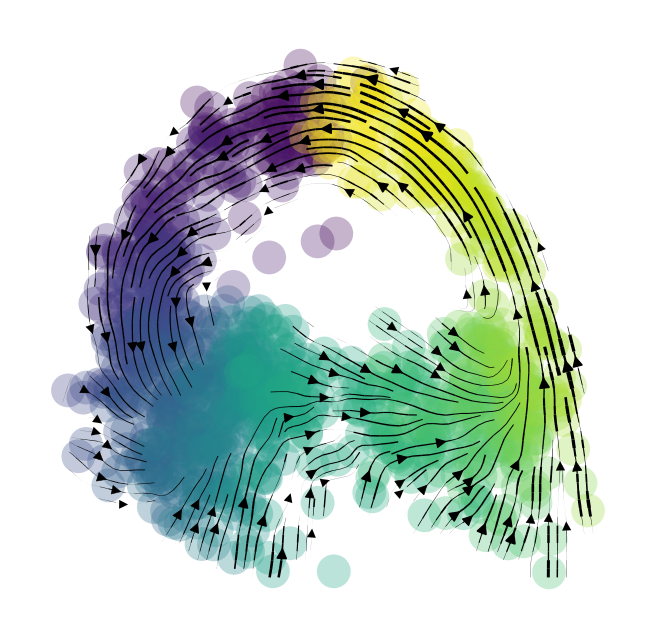

In [35]:
scv.pl.velocity_embedding_stream(
    latent_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='pseudotime', 
    title="",
    color_map='viridis',
    colorbar=False,
    figsize=(5,5),add_margin=0.1,
    # save='1.png'
)

saving figure to file figures/streamplot_KNSTRN_MELK.svg


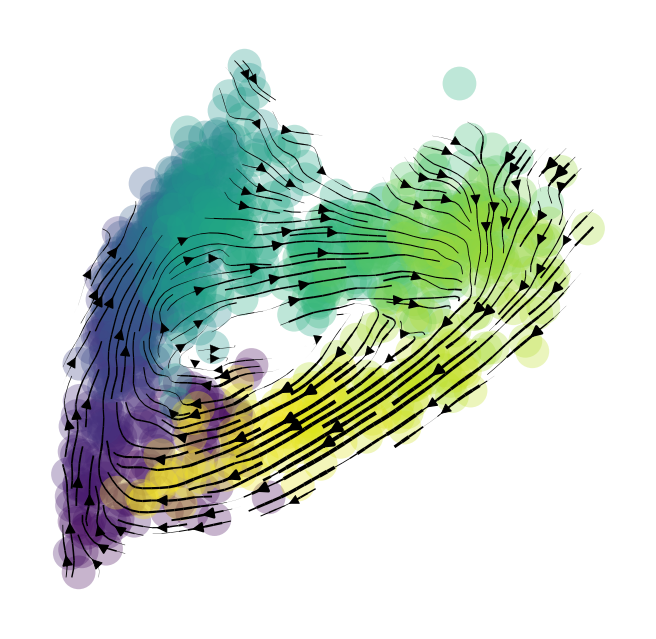

In [36]:
scv.pl.velocity_embedding_stream(
    latent_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='2dim', 
    color='pseudotime', 
    title="",
    color_map='viridis',
    colorbar=False,
    figsize=(5,5),add_margin=0.1,
    save=f'figures/streamplot_{gene1}_{gene2}.svg'
)

computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/22 cores)


  0%|          | 0/1040 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'spliced_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'spliced_velocity_pca', embedded velocity vectors (adata.obsm)


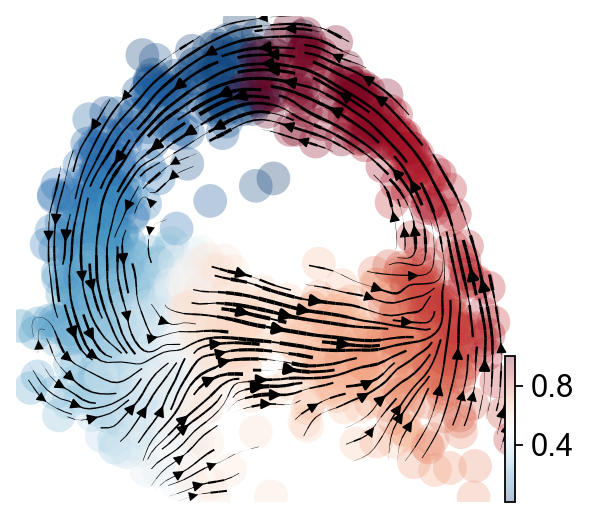

In [37]:
scv.pp.neighbors(latent_adata, n_neighbors=30, method='sklearn')
scv.tl.velocity_graph(latent_adata, vkey='spliced_velocity', xkey='spliced')
scv.tl.velocity_embedding(latent_adata, vkey='spliced_velocity', basis='pca')
scv.pl.velocity_embedding_stream(latent_adata,basis='pca',vkey='spliced_velocity', color='pseudotime',title="")

In [38]:
## 获得 basin_point重构表示
basin_point_reconstruct = basin_point @ new_weight.T + new_bias
basin_point_pca = (basin_point_reconstruct - np.mean(np_data, axis=0)) @ V

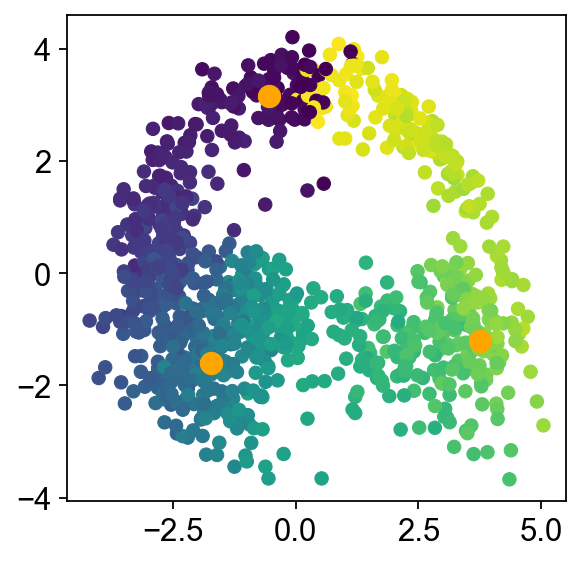

In [39]:
plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.viridis)
plt.scatter(basin_point_pca[:,0],basin_point_pca[:,1], c='orange', s=100)

Text(0.5, 1.0, 'CCNA2_CCNB1')

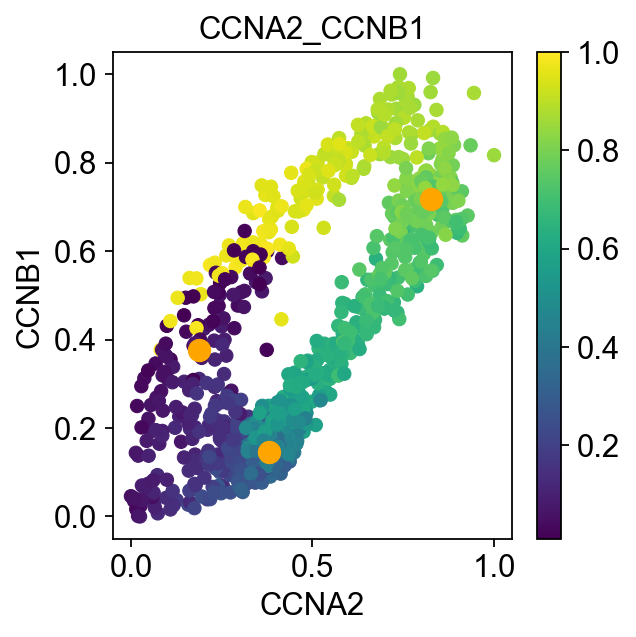

In [40]:
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
plt.scatter(np_data[:, index1], np_data[:, index2],c=th,cmap=cm.viridis)
plt.scatter(basin_point_reconstruct[:,index1],basin_point_reconstruct[:,index2], c='orange', s=100)
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(gene1)
plt.ylabel(gene2)
plt.title(gene1+'_'+gene2)

Text(0.5, 1.0, 'CCNA2_CCNB1')

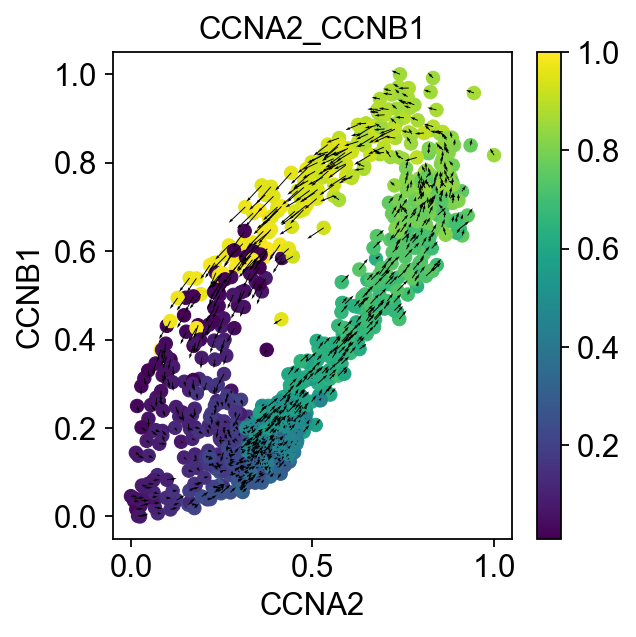

In [41]:
gene1 = 'CCNA2'
gene2 = 'CCNB1'
index1 = genes.index(gene1)
index2 = genes.index(gene2)
plt.scatter(np_data[:, index1], np_data[:, index2],c=th,cmap=cm.viridis)
plt.quiver(np_data[:, index1], np_data[:, index2], velocity_raw[:, index1], velocity_raw[:, index2],scale=50, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(gene1)
plt.ylabel(gene2)
plt.title(gene1+'_'+gene2)

# 量化MAP

Text(0, 0.5, 'PC2')

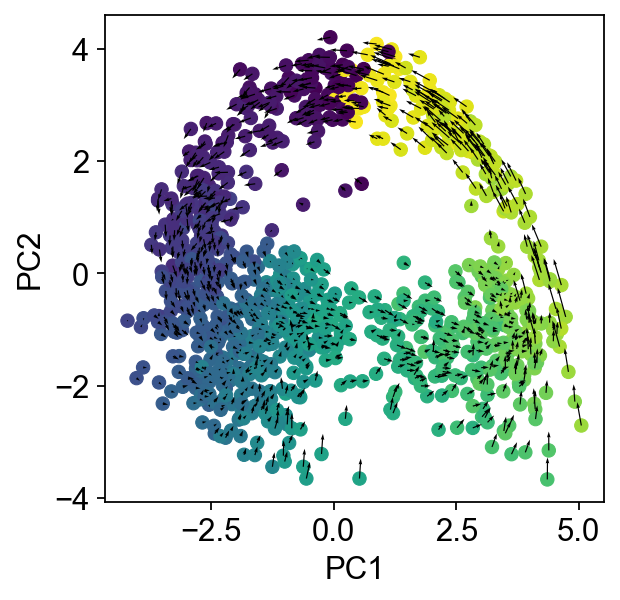

In [42]:
plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.viridis)
plt.quiver(np_data_pca[:, 0], np_data_pca[:, 1], velocity_approx_pca[:, 0], velocity_approx_pca[:, 1],scale=50, scale_units='xy')
plt.xlabel('PC1')
plt.ylabel('PC2')
# plt.savefig('1.png', dpi=300)

In [43]:
## 计算LAP
n_points = 30
EM_steps = 6

def compute_path(i, j, basin_point_pca, vf_func, jac_func, n_points, EM_steps):
    start = basin_point_pca[i,:]
    end = basin_point_pca[j,:]
    path, dt, action_opt = least_action_path(start, end, vf_func, jac_func, n_points=n_points, EM_steps=EM_steps, D=0.2)
    return {'start': i, 'end': j, 'path': path, 'dt': dt, 'action': action_opt}

# 并行计算
basin_index_pairs = [(0, 1), (1, 2), (2, 0), (0, 2), (1, 0), (2, 1)]
results_WT = Parallel(n_jobs=-1)(delayed(compute_path)(i, j, basin_point_pca, vf_func_pca, jac_func_diff, n_points, EM_steps) 
                              for i, j in basin_index_pairs
                             )

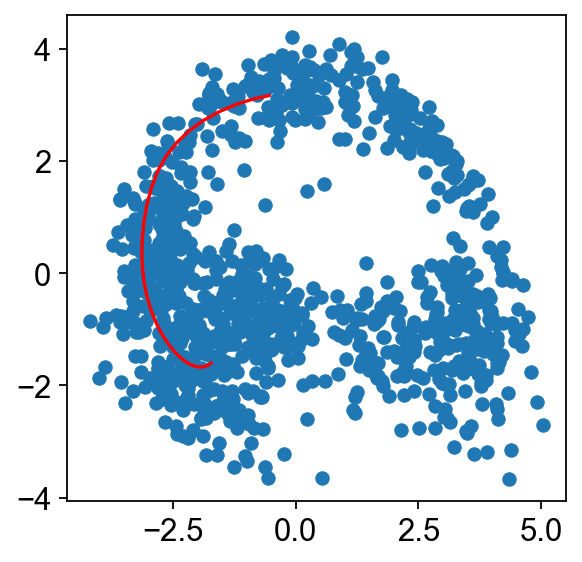

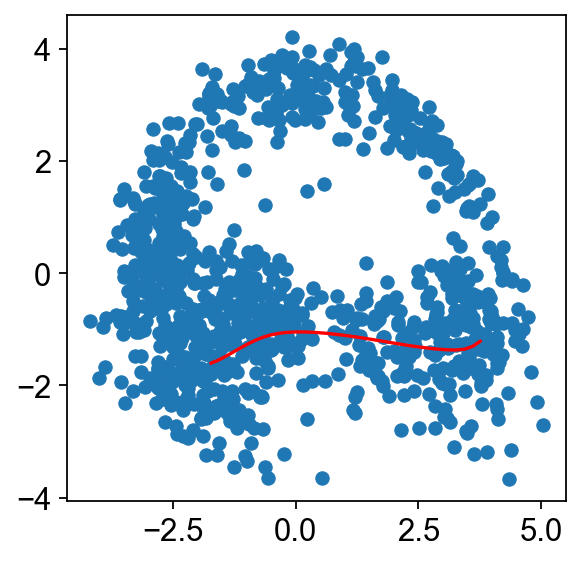

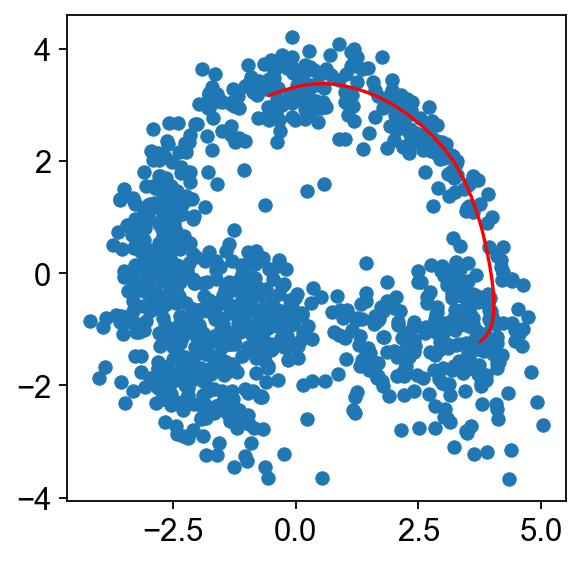

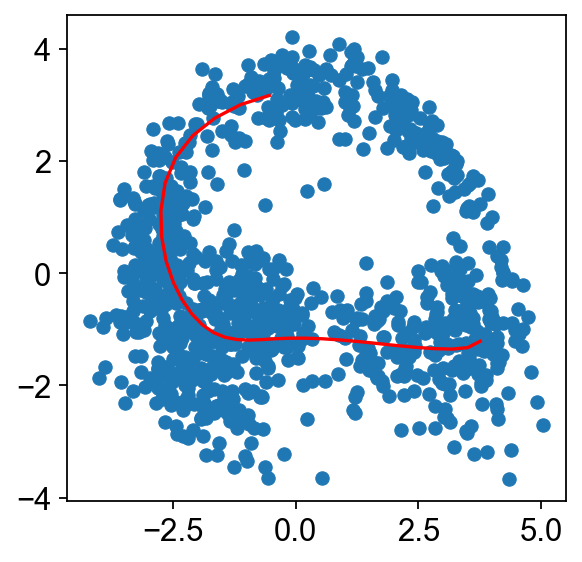

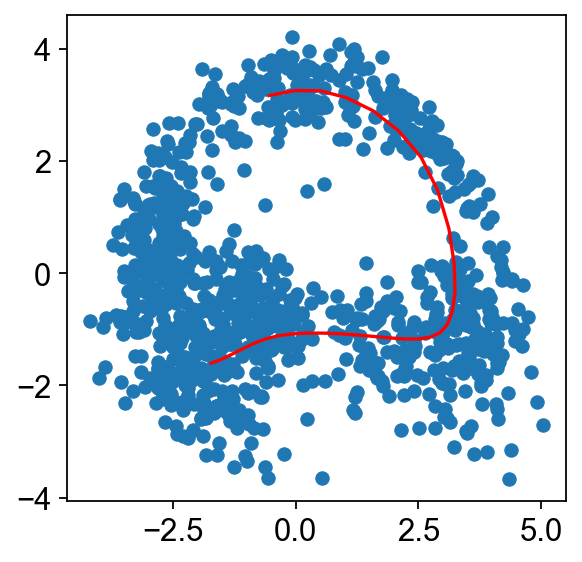

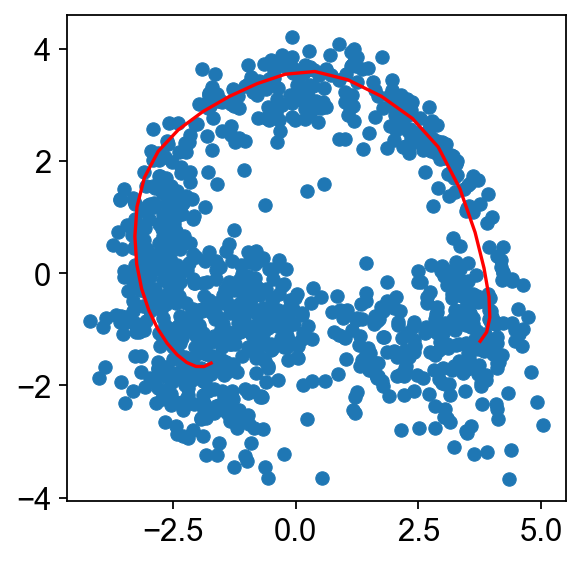

In [44]:
for i in range(len(results_WT)):
    plt.figure()
    plt.scatter(np_data_pca[:,0],np_data_pca[:,1])
    path = results_WT[i]['path']
    plt.plot(path[:,0],path[:,1], color='red')

In [45]:
results_WT

[{'start': 0,
  'end': 1,
  'path': array([[-5.44640474e-01,  3.16458533e+00,  8.21331423e-01,
           3.88295697e-01, -2.06073393e-01, -3.54984320e-01,
          -1.94743202e-01, -2.40271397e-01,  1.55303507e-01,
          -1.08665559e-01, -7.94454897e-02,  1.57316372e-01,
           7.37286150e-02,  4.61166505e-02,  3.11063766e-02,
           2.70742568e-02,  4.69160013e-02,  3.75709461e-02,
           1.80669840e-02, -6.19506031e-03],
         [-8.94669047e-01,  3.09692491e+00,  5.45698170e-01,
           4.88556269e-01, -9.57669506e-02, -4.28741820e-01,
          -1.58020380e-01, -2.10111472e-01,  1.58590397e-01,
          -9.82042155e-02, -6.22343589e-02,  1.45738736e-01,
           6.12633159e-02,  3.10922265e-02,  3.93257421e-02,
           2.06133758e-02,  4.01407357e-02,  3.99427859e-02,
           1.62786758e-02, -6.09292730e-03],
         [-1.23517884e+00,  3.00037262e+00,  2.66209260e-01,
           5.57287495e-01,  2.16943038e-02, -4.89122271e-01,
          -1.20064330e

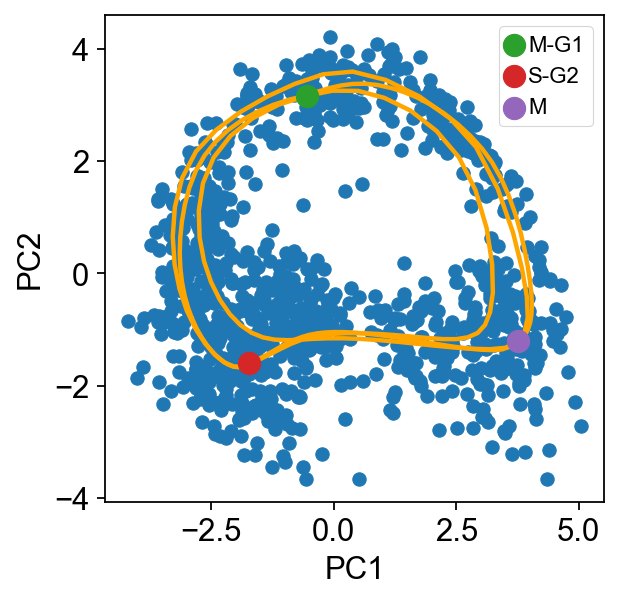

In [46]:
plt.scatter(np_data_pca[:,0],np_data_pca[:,1])
path = results_WT[0]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)
path = results_WT[1]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)
path = results_WT[2]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)
path = results_WT[3]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)
path = results_WT[4]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)
path = results_WT[5]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)

plt.scatter(basin_point_pca[0,0],basin_point_pca[0,1], c='#2CA02C', s=100, zorder=2, label='M-G1')
plt.scatter(basin_point_pca[1,0],basin_point_pca[1,1], c='#D62728', s=100, zorder=2, label='S-G2')
plt.scatter(basin_point_pca[2,0],basin_point_pca[2,1], c='#9467BD', s=100, zorder=2, label='M')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(fontsize=10)
# plt.savefig('1.png', dpi=300)

# 与极限环比较

In [47]:
# set initial points
# kk = 0.5
# x0 = np.ones((1, 2132))*kk
x0 = np_data[0,:].reshape(-1,1066)

# the length of sequence we predict
NK = 10000

t = torch.arange(0, 0.005 * NK, 0.005)

xx = np.zeros((1066, NK))

x1 = torch.as_tensor(x0, dtype=torch.float32)
encoded, _ = encoder(x1)
encoded = (encoded - mean)/std

latent_t = odeint(dynamics_learner, encoded, t, method='rk4')
latent_t = latent_t.permute(1, 2, 0).squeeze() # ode的解

for i in range(NK):
    encoded = latent_t[:, i]
    encoded = encoded * std + mean
    x0 = decoder(encoded)
    x0 = x0.detach().numpy()
    xx[:, i] = x0
    
latent_t = latent_t.detach().numpy()

In [48]:
xx_pca = (xx.T - np.mean(np_data, axis=0)) @ V

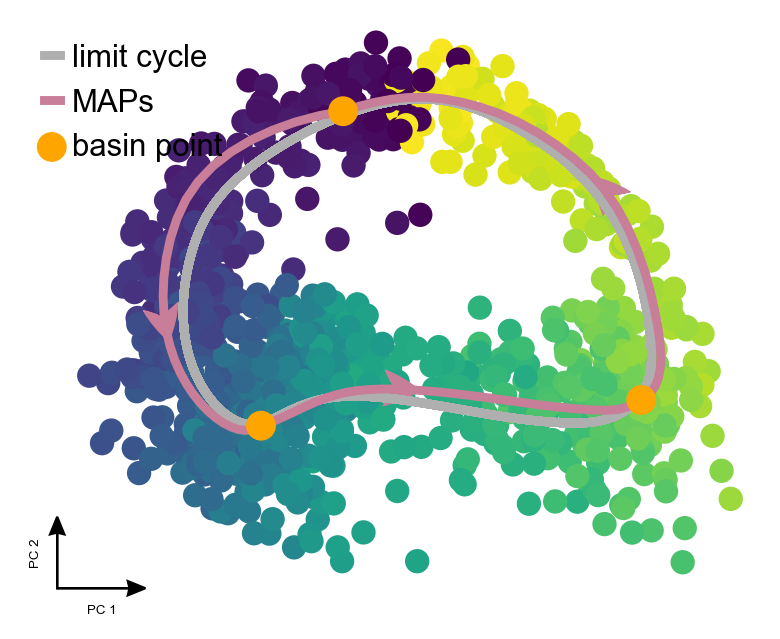

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np_data_pca[:, 0], np_data_pca[:, 1], c=th, cmap=cm.viridis, s=120, alpha=1, edgecolors='none', rasterized=True)
ax.plot(xx_pca[5000:, 0], xx_pca[5000:, 1], linewidth=4.0, color='#afafaf', label='limit cycle')
path = results_WT[0]['path']
ax.plot(path[:,0],path[:,1], color='#c87d98', linewidth=4, label='MAPs')
arrow = FancyArrowPatch((path[15, 0], path[15, 1]), 
                        (path[16, 0], path[16, 1]),
                        arrowstyle='fancy', mutation_scale=40, color='#c87d98')
ax.add_patch(arrow)
path = results_WT[1]['path']
ax.plot(path[:,0],path[:,1], color='#c87d98', linewidth=4)
arrow = FancyArrowPatch((path[15, 0], path[15, 1]), 
                        (path[16, 0], path[16, 1]),
                        arrowstyle='fancy', mutation_scale=40, color='#c87d98')
ax.add_patch(arrow)
path = results_WT[2]['path']
ax.plot(path[:,0],path[:,1], color='#c87d98', linewidth=4)
arrow = FancyArrowPatch((path[15, 0], path[15, 1]), 
                        (path[16, 0], path[16, 1]),
                        arrowstyle='fancy', mutation_scale=40, color='#c87d98')
ax.add_patch(arrow)
ax.scatter(basin_point_pca[:,0],basin_point_pca[:,1], c='orange', s=180, edgecolors='none', zorder=2, label='basin point')
arrowed_spines(ax, columns='PC')
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('figures/MAP_LC_compare.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

# 施加基因扰动

In [50]:
## 选取感兴趣的基因列表
# genes_interest = ['CDK1',
#  'FAM83D',
#  'UBE2C',
#  'FBXO5',
#  'PSRC1',
#  'E2F4',
#  'CCNF',
#  'TOP2A',
#  'HSPA8',
#  'DDX3X',
#  'NAA50',
#  'BORA',
#  'CDC6',
#  'CNOT9',
#  'MCM3',
#  'CDC25A',
#  'NSUN2',
#  'HSP90AB1',
#  'CEP192',
#  'CENPC']

# genes_interest = [
#     "CCND1","CCND2","CCND3",
#     "CDK4", "CDK6",
#     "CCNE1", "CCNE2",
#     "RB1",
#     "E2F1", "E2F2", "E2F3",
#     "CCNA2",
#     "CDK2","CDK1",
#     "CDH1","CDC20",
#     "CCNB1","CCNB2",
#     "WEE1",
#     "CDC25A", "CDC25B", "CDC25C",
#     "CDKN1A", "CDKN1B",
# ]

genes_interest = genes

index_interest = [genes.index(gene) for gene in genes_interest if gene in genes]
g = [gene for gene in genes_interest if gene in genes]

In [51]:
## VeloCycle中等基因列表
MEDIUM_CYCLING_GENE_SET = np.array(['Ankrd17', 'Anln', 'Anp32b', 'Anp32e', 'Apbb2', 'Arl6ip1', 'Aspm',
       'Atad2', 'Atrx', 'Aurka', 'Aurkb', 'Azin1', 'Birc5', 'Blm', 'Bora',
       'Brca2', 'Brd4', 'Brip1', 'Bub1', 'Bub1b', 'Bub3', 'Calm2', 'Calr',
       'Casp8ap2', 'Cbx5', 'Ccna2', 'Ccnb1', 'Ccnb2', 'Ccnd1', 'Ccne1',
       'Ccne2', 'Ccnf', 'Cdc20', 'Cdc25a', 'Cdc25c', 'Cdc26', 'Cdc27',
       'Cdc45', 'Cdc6', 'Cdca2', 'Cdca3', 'Cdca5', 'Cdca7', 'Cdca8',
       'Cdk1', 'Cdk5rap2', 'Cdk7', 'Cdk9', 'Cdkn1b', 'Cdkn2d', 'Cdkn3',
       'Cdt1', 'Cenpa', 'Cenpe', 'Cenpf', 'Cenpu', 'Cep120', 'Cep192',
       'Cep85', 'Chaf1b', 'Chek2', 'Chmp5', 'Chordc1', 'Cit', 'Ckap2',
       'Ckap2l', 'Ckap5', 'Cks1b', 'Cks2', 'Clspn', 'Cradd', 'Crebbp',
       'Crlf3', 'Ctcf', 'Dbf4', 'Dctn1', 'Ddx11', 'Dlgap5', 'Dot1l',
       'Dscc1', 'Dtl', 'Dync1li1', 'Dyrk3', 'E2f1', 'E2f3', 'E2f8',
       'Ect2', 'Esco2', 'Exo1', 'Ezh2', 'Fam83d', 'Fbxo5', 'Fen1', 'Fzr1',
       'G2e3', 'Gadd45b', 'Gas2l3', 'Gigyf2', 'Gins2', 'Gmnn', 'Gtse1',
       'Hat1', 'Hells', 'Hjurp', 'Hmgb2', 'Hmmr', 'Hsp90ab1', 'Hspa8',
       'Incenp', 'Ino80', 'Jade1', 'Jan1', 'Jpt1', 'Junb', 'Kif11',
       'Kif14', 'Kif20a', 'Kif20b', 'Kif23', 'Kif2c', 'Kif4', 'Kifc1',
       'Lbr', 'Mad1l1', 'Mad2l1', 'Mastl', 'Mcm2', 'Mcm4', 'Mcm5', 'Mcm6',
       'Mcph1', 'Mepce', 'Mis18bp1', 'Mki67', 'Msh2', 'Nanog', 'Nasp',
       'Ncapd2', 'Ndc80', 'Nek2', 'Nipbl', 'Nuf2', 'Numa1', 'Nusap1',
       'Orc1', 'Pcna', 'Phb2', 'Phip', 'Pik3c3', 'Pimreg', 'Pin1', 'Pkp4',
       'Plk1', 'Pola1', 'Pold3', 'Ppp2ca,', 'Prc1', 'Prim1', 'Psrc1',
       'Pttg1', 'Pum1', 'Racgap1', 'Rad21', 'Rad50', 'Rad51', 'Rad51ap1',
       'Ranbp1', 'Rangap1', 'Rbm38', 'Rcc1', 'Rdx', 'Rfc2', 'Rhoa',
       'Riok2', 'Rnf167', 'Rnf4', 'Rpa2', 'Rpa3', 'Rptor', 'Rrm1', 'Rrm2',
       'Sde2', 'Senp6', 'Sfpq', 'Sgo2a', 'Slbp', 'Smc4', 'Son', 'Spag5',
       'Spdl1', 'Srpk2', 'Tacc3', 'Taf6', 'Taok3', 'Tfdp2', 'Ticrr',
       'Timeless', 'Tipin', 'Tmpo', 'Top2a', 'Topbp1', 'Tpx2', 'Trim59',
       'Ttc28', 'Ttk', 'Tuba1c', 'Tubb4b', 'Tyms', 'Ube2c', 'Ubr7',
       'Uhrf1', 'Ung', 'Usp1', 'Wdr76', 'Wee1', 'Ythdf2', 'Zfp36l1',
       'Zwint'])

# genes_interest = ["WT",
# 'CCNA2', 'CCNB1', 'CCNB2', 'CCND1',
# 'CCNE1', 'CCNF', 'CDC20', 'CDC25A', 'CDC25C', 'CDC27', 'CDC6', 'CDCA8', 'CDK1',
# 'CDT1', 'CENPA', 'CENPE', 'CENPF','E2F1', 'E2F3',
# 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'ORC1', 'PCNA'
# ]
MEDIUM_CYCLING_GENE_SET = np.array([i.upper() for i in MEDIUM_CYCLING_GENE_SET])
intersection = np.intersect1d(MEDIUM_CYCLING_GENE_SET, g)

In [52]:
## 计算PCA降维后的近似向量场
velocity_perturb = vf_func_pca(np_data_pca, index=155, k=100)

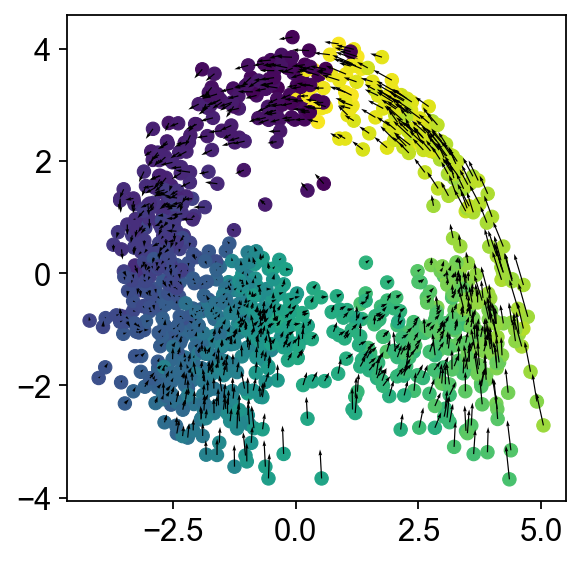

In [53]:
plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.viridis)
plt.quiver(np_data_pca[:, 0], np_data_pca[:, 1], velocity_perturb[:, 0], velocity_perturb[:, 1],scale=50, scale_units='xy')

In [54]:
# ## 计算LAP
# n_points = 30
# EM_steps = 6
# basin_index_pairs = [(0, 1), (1, 2), (2, 0)]

# def compute_path(gene_index, basin_index_pairs, basin_point_pca, vf_func_pca, jac_func_pca, n_points, EM_steps):
#     vf_func_perturb = partial(vf_func_pca, index=gene_index, k=50)
#     # jac_func_perturb = partial(jac_func_pca, index=gene_index, k=50)
#     jac_func_perturb = partial(jac_func_pca, func=vf_func_perturb)
#     results = []
#     for i, j in basin_index_pairs:
#         start = basin_point_pca[i,:]
#         end = basin_point_pca[j,:]
#         path, dt, action_opt = least_action_path(start, end, vf_func_perturb, jac_func_perturb, n_points=n_points, EM_steps=EM_steps, D=0.2)
#         results.append({'gene_index': gene_index, 'start': i, 'end': j, 'path': path, 'dt': dt, 'action': action_opt})
    
#     return results

# # 并行计算
# with tqdm_joblib(tqdm(total=len(index_interest), desc="Computing paths")) as progress_bar:
#     results = Parallel(n_jobs=20)(
#         delayed(compute_path)(
#             gene_index,
#             basin_index_pairs,
#             basin_point_pca,
#             vf_func_pca,
#             jac_func_diff,
#             n_points,
#             EM_steps
#         )
#         for gene_index in index_interest
#     )

In [55]:
# with open('perturb_all_results.pkl', 'wb') as f:
#     pickle.dump(results, f)

In [56]:
# action_results = []
# action_results.append({'gene': 'WT', 'action of G1->S': results_WT[0]['action'], 'action of S->G2M': results_WT[1]['action'], 
#                        'action of G2M->G1': results_WT[2]['action'], 'time of G1->S': results_WT[0]['dt'] * n_points, 
#                        'time of S->G2M': results_WT[1]['dt'] * n_points, 'time of G2M->G1': results_WT[2]['dt'] * n_points})
# for i in range(len(results)):
#     gene = g[i]
#     action1 = results[i][0]['action']
#     action2 = results[i][1]['action']
#     action3 = results[i][2]['action']
#     t1 = results[i][0]['dt'] * n_points
#     t2 = results[i][1]['dt'] * n_points
#     t3 = results[i][2]['dt'] * n_points
#     action_results.append({'gene': gene, 'action of G1->S': action1, 'action of S->G2M': action2, 'action of G2M->G1': action3, 
#                            'time of G1->S': t1, 'time of S->G2M': t2, 'time of G2M->G1': t3})

# action_results_df = pd.DataFrame(action_results)
# action_results_df

In [57]:
# with open('perturb_df_results.pkl', 'wb') as f:
#     pickle.dump(action_results_df, f)

In [58]:
with open('perturb_all_results.pkl', 'rb') as f:
    results = pickle.load(f)

with open('perturb_df_results.pkl', 'rb') as f:
    action_results_df = pickle.load(f)

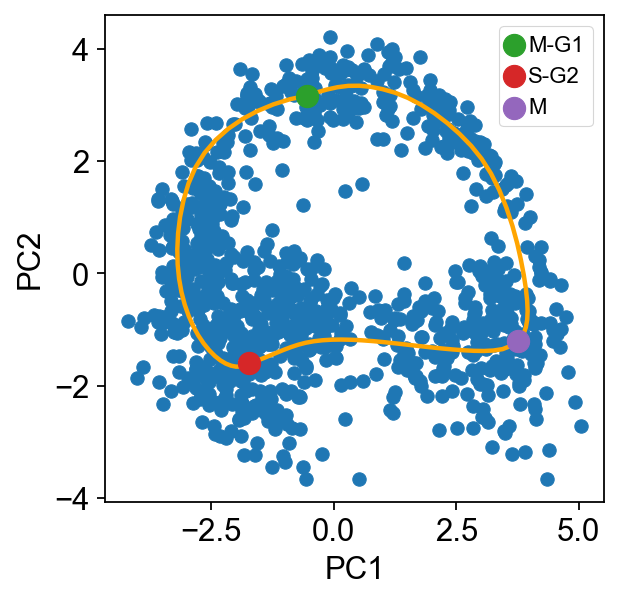

In [59]:
plt.scatter(np_data_pca[:,0],np_data_pca[:,1])
path = results[0][0]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)
path = results[0][1]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)
path = results[0][2]['path']
plt.plot(path[:,0],path[:,1], color='orange', linewidth=2)

plt.scatter(basin_point_pca[0,0],basin_point_pca[0,1], c='#2CA02C', s=100, zorder=2, label='M-G1')
plt.scatter(basin_point_pca[1,0],basin_point_pca[1,1], c='#D62728', s=100, zorder=2, label='S-G2')
plt.scatter(basin_point_pca[2,0],basin_point_pca[2,1], c='#9467BD', s=100, zorder=2, label='M')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(fontsize=10)

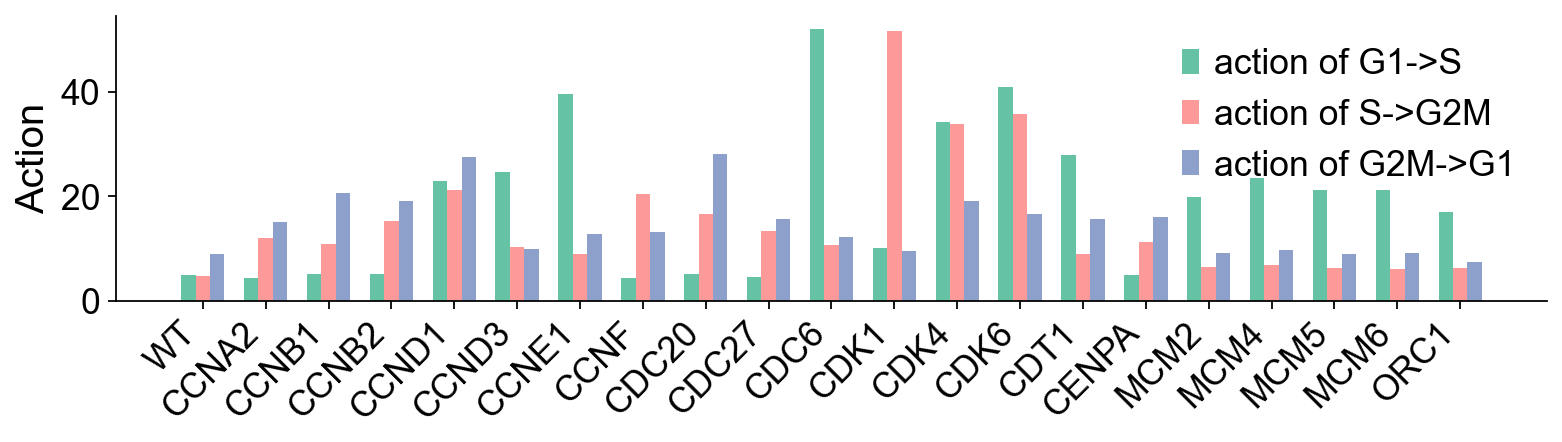

In [60]:
# genes_interest = ['WT',
# 'CCNA2', 'CCNB1', 'CCNB2', 'CCND1', 'CCND3', 'CCNE1', 'CCNF', 'CDC20',
# 'CDC25A', 'CDC25B', 'CDC25C', 'CDC27', 'CDC6', 'CDCA8', 'CDK1', 'CDK4', 'CDK6',
# 'CDT1', 'CENPA', 'CENPE', 'CENPF', 'E2F1', 'E2F2', 'E2F3',
# 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'ORC1', 'PCNA'
# ]

genes_interest = ['WT',
'CCNA2', 'CCNB1', 'CCNB2', 'CCND1', 'CCND3', 'CCNE1', 'CCNF', 'CDC20',
'CDC27', 'CDC6', 'CDK1', 'CDK4', 'CDK6',
'CDT1', 'CENPA',
'MCM2', 'MCM4', 'MCM5', 'MCM6', 'ORC1',
]
genes_interest_df = action_results_df[action_results_df.iloc[:, 0].isin(genes_interest)]

categories = ['action of G1->S', 'action of S->G2M', 'action of G2M->G1']

x = range(len(genes_interest_df))  # 每个基因的位置
width = 0.23  # 每组柱子的宽度

plt.figure(figsize=(10, 3))

# 为每个类别绘制柱子
colors = ['#66c2a5',
          '#fb9a99',
          '#8da0cb']
for i, category in enumerate(categories):
    offsets = [pos + (i - (len(categories)-1)/2) * width for pos in x]  # 确保柱子分组排列
    plt.bar(offsets, genes_interest_df[category], width=width, label=category, color=colors[i])

# 添加细节
# plt.xlabel('Genes', fontsize=20)
plt.ylabel('Action', fontsize=18)
plt.xticks(range(len(genes_interest_df)), genes_interest_df['gene'], rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16, frameon=False)

# 突出 "WT"
# for tick in plt.gca().get_xticklabels():
#     if tick.get_text() == 'WT': 
#         tick.set_fontweight('bold')
#         tick.set_color('red')
#         tick.set_fontsize(18)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

plt.savefig('figures/action of core genes.svg', bbox_inches='tight', transparent=True)
plt.show()

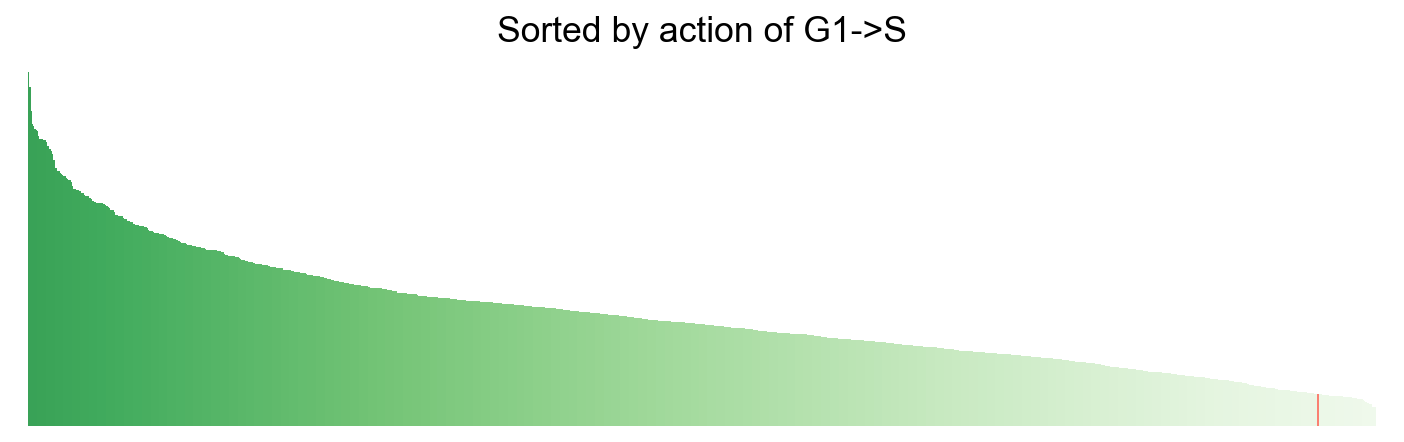

In [61]:
column = 'action of G1->S'
sorted_df = action_results_df.sort_values(by=column, ascending=False)
values = sorted_df[column].values
genes = sorted_df['gene'].values

# 创建一个从 0 到 1 的归一化色条
norm = plt.Normalize(vmin=-100, vmax=len(genes) + 600)
cmap = plt.cm.Greens  # 渐变色

# 为每个柱子选择颜色
colors = []
for idx, (gene, value) in enumerate(zip(genes, values)):
    if gene == 'WT':
        colors.append('salmon')
    else:
        colors.append(cmap(norm(len(genes) - 1- idx)))

# 绘图
fig, ax = plt.subplots(figsize=(9, 3))
bars = ax.bar(range(len(genes)), values, color=colors, width=1.0)  # width=1去掉空隙

# 去掉所有边框和坐标轴
ax.axis('off')

plt.title(f'Sorted by {column}', fontsize=16)

plt.xlim(-10, len(genes) + 10)
plt.tight_layout()

safe_column = re.sub(r'[<>:"/\\|?*]', '_', column) 
filename = f"figures/sorted_by_{safe_column}.svg"  # 设置每张图片的文件名
plt.savefig(filename, bbox_inches='tight', transparent=True)
plt.show()

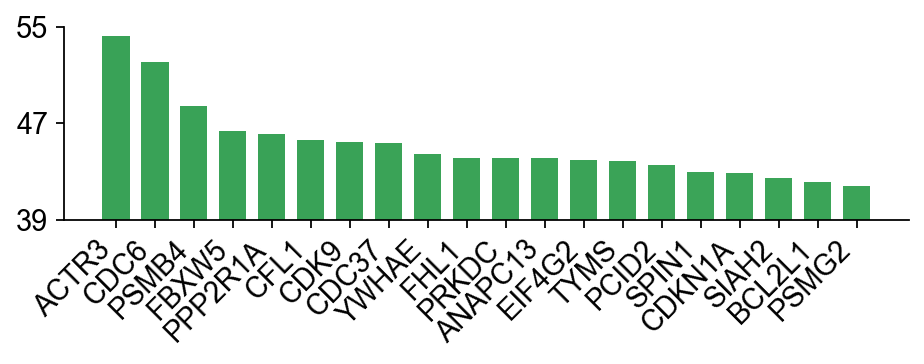

In [62]:
top_20_indices = range(20)

# 提取选中的基因、数值和颜色
selected_genes = genes[top_20_indices]
selected_values = values[top_20_indices]
selected_colors = [colors[i] for i in top_20_indices]

# 绘图
fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.bar(selected_genes, selected_values, color=selected_colors, width=0.7)

ax.set_ylim([39, 55])
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 3)
ax.set_yticks(yticks)
# ax.set_xlabel('Genes', fontsize=14)
# ax.set_ylabel('Action', fontsize=14)
ax.set_xticklabels(selected_genes, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=13)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
  
plt.tight_layout()
plt.savefig('figures/action of MG1_S high.svg', bbox_inches='tight', transparent=True)
plt.show()

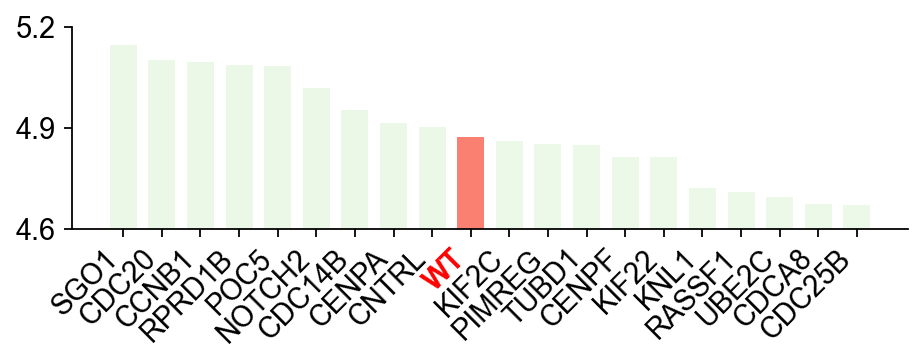

In [63]:
wt_index = np.where(genes == 'WT')[0][0]
wt_neighbors_indices = range(wt_index - 9, wt_index + 11)

# 提取选中的基因、数值和颜色
selected_genes = genes[wt_neighbors_indices]
selected_values = values[wt_neighbors_indices]
selected_colors = [colors[i] for i in wt_neighbors_indices]

# 绘图
fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.bar(selected_genes, selected_values, color=selected_colors, width=0.7)

ax.set_ylim([4.6, 5.2])
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 3)
ax.set_yticks(yticks)
# ax.set_yticklabels([f"{y:.1f}" for y in yticks])
# ax.set_xlabel('Genes', fontsize=14)
# ax.set_ylabel('Action', fontsize=14)
ax.set_xticklabels(selected_genes, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=13)

for tick in plt.gca().get_xticklabels():  # 获取当前图表的x轴刻度标签
    if tick.get_text() == 'WT':  # 判断标签是否为 "WT"
        tick.set_fontweight('bold')  # 加粗
        tick.set_color('red')       # 设置颜色为红色
        tick.set_fontsize(13)       # 调整字体大小

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
  
plt.tight_layout()
plt.savefig('figures/action of MG1_S low.svg', bbox_inches='tight', transparent=True)
plt.show()

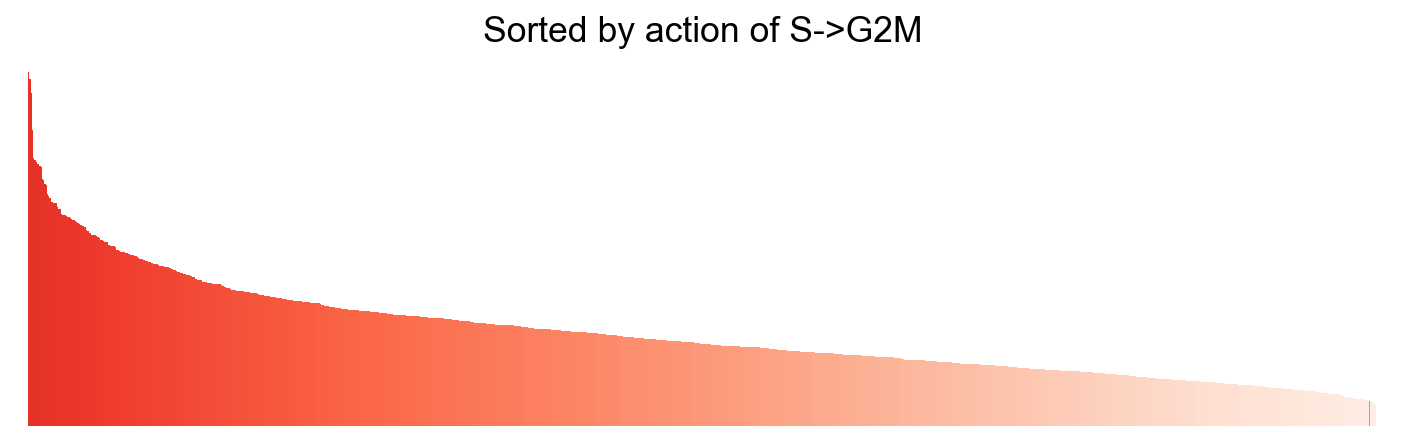

In [64]:
column = 'action of S->G2M'
sorted_df = action_results_df.sort_values(by=column, ascending=False)
values = sorted_df[column].values
genes = sorted_df['gene'].values

# 创建一个从 0 到 1 的归一化色条
norm = plt.Normalize(vmin=-100, vmax=len(genes) + 600)
cmap = plt.cm.Reds  # 渐变色

# 为每个柱子选择颜色
colors = []
for idx, (gene, value) in enumerate(zip(genes, values)):
    if gene == 'WT':
        colors.append('salmon')
    else:
        colors.append(cmap(norm(len(genes) - 1- idx)))

# 绘图
fig, ax = plt.subplots(figsize=(9, 3))
bars = ax.bar(range(len(genes)), values, color=colors, width=1.0)  # width=1去掉空隙

# 去掉所有边框和坐标轴
ax.axis('off')

plt.title(f'Sorted by {column}', fontsize=16)

plt.xlim(-10, len(genes) + 10)
plt.tight_layout()

safe_column = re.sub(r'[<>:"/\\|?*]', '_', column) 
filename = f"figures/sorted_by_{safe_column}.svg"  # 设置每张图片的文件名
plt.savefig(filename, bbox_inches='tight', transparent=True)
plt.show()

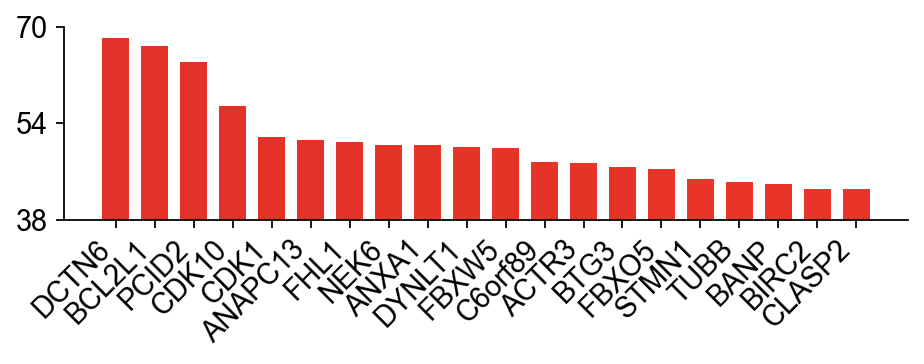

In [65]:
top_20_indices = range(20)

# 提取选中的基因、数值和颜色
selected_genes = genes[top_20_indices]
selected_values = values[top_20_indices]
selected_colors = [colors[i] for i in top_20_indices]

# 绘图
fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.bar(selected_genes, selected_values, color=selected_colors, width=0.7)

ax.set_ylim([38, 70])
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 3)
ax.set_yticks(yticks)
# ax.set_xlabel('Genes', fontsize=14)
# ax.set_ylabel('Action', fontsize=14)
ax.set_xticklabels(selected_genes, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=13)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
  
plt.tight_layout()
plt.savefig('figures/action of S_G2M high.svg', bbox_inches='tight', transparent=True)
plt.show()

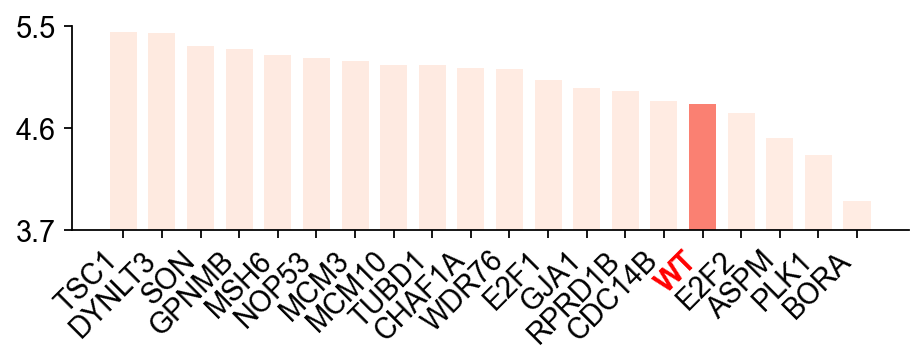

In [66]:
wt_index = np.where(genes == 'WT')[0][0]
wt_neighbors_indices = range(wt_index - 15, wt_index + 5)

# 提取选中的基因、数值和颜色
selected_genes = genes[wt_neighbors_indices]
selected_values = values[wt_neighbors_indices]
selected_colors = [colors[i] for i in wt_neighbors_indices]

# 绘图
fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.bar(selected_genes, selected_values, color=selected_colors, width=0.7)

ax.set_ylim([3.7, 5.5])
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 3)
ax.set_yticks(yticks)
# ax.set_xlabel('Genes', fontsize=14)
# ax.set_ylabel('Action', fontsize=14)
ax.set_xticklabels(selected_genes, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=13)

for tick in plt.gca().get_xticklabels():  # 获取当前图表的x轴刻度标签
    if tick.get_text() == 'WT':  # 判断标签是否为 "WT"
        tick.set_fontweight('bold')  # 加粗
        tick.set_color('red')       # 设置颜色为红色
        tick.set_fontsize(13)       # 调整字体大小

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
  
plt.tight_layout()
plt.savefig('figures/action of S_G2M low.svg', bbox_inches='tight', transparent=True)
plt.show()

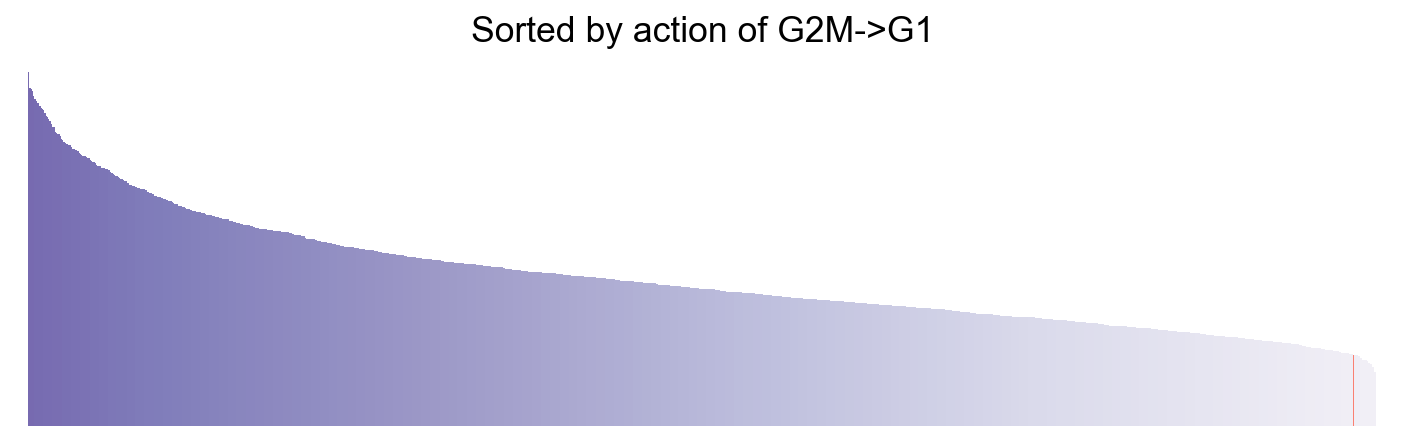

In [67]:
column = 'action of G2M->G1'
sorted_df = action_results_df.sort_values(by=column, ascending=False)
values = sorted_df[column].values
genes = sorted_df['gene'].values

# 创建一个从 0 到 1 的归一化色条
norm = plt.Normalize(vmin=-200, vmax=len(genes) + 600)
cmap = plt.cm.Purples  # 渐变色

# 为每个柱子选择颜色
colors = []
for idx, (gene, value) in enumerate(zip(genes, values)):
    if gene == 'WT':
        colors.append('salmon')
    else:
        colors.append(cmap(norm(len(genes) - 1- idx)))

# 绘图
fig, ax = plt.subplots(figsize=(9, 3))
bars = ax.bar(range(len(genes)), values, color=colors, width=1.0)  # width=1去掉空隙

# 去掉所有边框和坐标轴
ax.axis('off')

plt.title(f'Sorted by {column}', fontsize=16)

plt.xlim(-10, len(genes) + 10)
plt.tight_layout()

safe_column = re.sub(r'[<>:"/\\|?*]', '_', column) 
filename = f"figures/sorted_by_{safe_column}.svg"  # 设置每张图片的文件名
plt.savefig(filename, bbox_inches='tight', transparent=True)
plt.show()

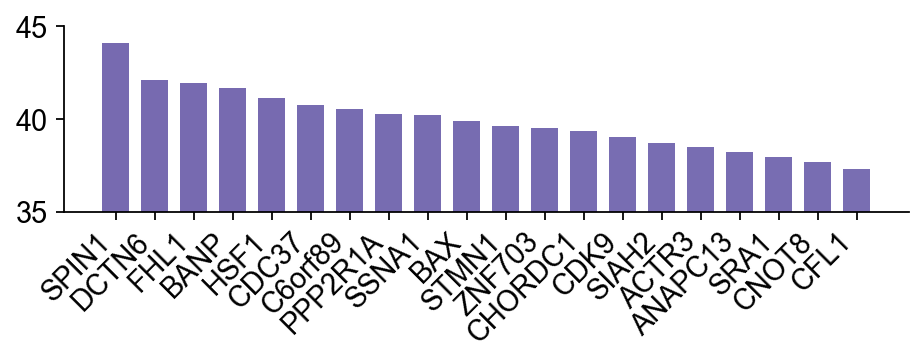

In [68]:
top_20_indices = range(20)

# 提取选中的基因、数值和颜色
selected_genes = genes[top_20_indices]
selected_values = values[top_20_indices]
selected_colors = [colors[i] for i in top_20_indices]

# 绘图
fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.bar(selected_genes, selected_values, color=selected_colors, width=0.7)

ax.set_ylim([35, 45])
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 3)
ax.set_yticks(yticks)
# ax.set_xlabel('Genes', fontsize=14)
# ax.set_ylabel('Action', fontsize=14)
ax.set_xticklabels(selected_genes, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=13)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
  
plt.tight_layout()
plt.savefig('figures/action of G2M_MG1 high.svg', bbox_inches='tight', transparent=True)
plt.show()

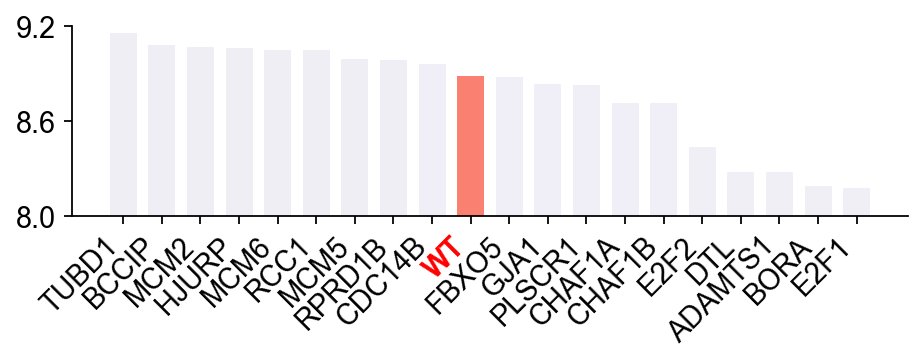

In [69]:
wt_index = np.where(genes == 'WT')[0][0]
wt_neighbors_indices = range(wt_index - 9, wt_index + 11)

# 提取选中的基因、数值和颜色
selected_genes = genes[wt_neighbors_indices]
selected_values = values[wt_neighbors_indices]
selected_colors = [colors[i] for i in wt_neighbors_indices]

# 绘图
fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.bar(selected_genes, selected_values, color=selected_colors, width=0.7)

ax.set_ylim([8.0, 9.2])
yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 3)
ax.set_yticks(yticks)
# ax.set_xlabel('Genes', fontsize=14)
# ax.set_ylabel('Action', fontsize=14)
ax.set_xticklabels(selected_genes, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=13)

for tick in plt.gca().get_xticklabels():  # 获取当前图表的x轴刻度标签
    if tick.get_text() == 'WT':  # 判断标签是否为 "WT"
        tick.set_fontweight('bold')  # 加粗
        tick.set_color('red')       # 设置颜色为红色
        tick.set_fontsize(13)       # 调整字体大小

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
  
plt.tight_layout()
plt.savefig('figures/action of G2M_MG1 low.svg', bbox_inches='tight', transparent=True)
plt.show()